
# 12. Exploratory Data Analysis, Visualization, and Summary Statistics

Exploratory data analysis is where statistical judgment begins to touch the data itself. Before we fit a regression, build a classifier, or estimate a treatment effect, we need to understand what kind of dataset we actually have: what is measured, what is missing, what is extreme, what looks suspicious, and what patterns might matter later.

In decision science, this is not a decorative step. It is where we learn whether the data support the question we want to answer. A neat model fit to a dirty, poorly understood dataset can be less useful than a careful descriptive analysis that reveals bad coding, non-random missingness, hidden subgroup structure, or leakage.

We use a synthetic premium-support operations dataset. The immediate business question is whether support leaders can understand drivers of ticket-resolution time and SLA failure well enough to decide what modeling work is safe to do next.



## Learning Objectives

After working through this lecture, you should be able to:

1. Explain what EDA is for and what it is not for.
2. Build a first-pass dataset audit that summarizes variable types, missingness, and cardinality.
3. Use summary statistics that reflect shape, skew, tail risk, and the mean together.
4. Compare subgroups in a way that respects both effect size and sample size.
5. Detect missingness patterns, coding errors, and suspicious values that can distort later modeling.
6. Recognize leakage clues and distinguish pre-outcome variables from post-outcome artifacts.
7. Convert an exploratory analysis into a concrete handoff for subsequent statistical modeling.


## Mathematical Core: EDA as Estimating Basic Features of the Data-Generating Process

Exploratory data analysis estimates simple but important features of the joint distribution of variables. For a numeric variable `X`, the sample mean and sample variance are

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i,
\qquad
s_X^2 = \frac{1}{n-1}\sum_{i=1}^{n} \left(X_i - \bar{X}\right)^2.
$$

Because many operational variables are skewed, quantiles are often more robust summaries:

$$
\widehat{q}_p = \inf \left\{x : \widehat{F}_n(x) \ge p\right\}.
$$

Missingness is itself a variable. If `M_i = 1` means a value is missing, then the missingness rate is

$$
\widehat{P}(M = 1) = \frac{1}{n}\sum_{i=1}^{n} M_i.
$$

Group comparisons estimate conditional summaries:

$$
\mathbb{E}[Y \mid G = g],
\qquad
\mathbb{E}[Y \mid G = g_1] - \mathbb{E}[Y \mid G = g_0].
$$

Pairwise association is often summarized by correlation,

$$
r_{XY} =
\frac{\sum_{i=1}^{n} \left(X_i - \bar{X}\right)\left(Y_i - \bar{Y}\right)}
{\sqrt{\sum_{i=1}^{n} \left(X_i - \bar{X}\right)^2}\sqrt{\sum_{i=1}^{n} \left(Y_i - \bar{Y}\right)^2}}.
$$

Correlation is only an association diagnostic. EDA should surface structure, anomalies, missingness, leakage, and measurement issues before any formal model is trusted.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.4f}".format
pd.options.display.max_colwidth = None


def display_wrapped(df, max_width="440px"):
    """
    Display tabular output with notebook-friendly wrapping for long text fields.
    
    Parameters:
        df: Input DataFrame used by the summary, model, or display helper.
        max_width: Maximum displayed cell width for wrapped pandas output.
    
    Returns:
        The IPython display result for a pandas object styled with wrapped text, so long table entries remain readable in the notebook.
    
    Idea:
        Improve table readability in rendered notebooks so long labels and explanations support teaching without visual clipping.
    """
    return smart_display(
        df.style.set_properties(
            subset=pd.IndexSlice[:, :],
            **{
                "white-space": "normal",
                "max-width": max_width,
                "text-align": "left",
            },
        ).set_table_styles(
            [
                {"selector": "th", "props": [("white-space", "normal"), ("text-align", "left")]},
                {"selector": "td", "props": [("vertical-align", "top")]},
            ]
        )
    )

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display


## 1. What EDA Is Trying to Accomplish

Exploratory data analysis is disciplined curiosity. The goal is not to prove a final claim from every picture, and it is not to hunt for whatever pattern looks exciting. The goal is to build a trustworthy understanding of the dataset before formal modeling begins.

A good exploratory pass should answer questions like these:

- What does each variable represent, and when is it observed?
- How many observations do we have, and how many are missing or suspicious?
- Are the outcomes symmetric, skewed, heavy-tailed, or bounded?
- Do subgroup differences change after conditioning on another variable?
- Are any variables obviously post-outcome and therefore dangerous as predictors?

Those questions sound simple, but they often decide whether the next model will be insightful, fragile, or completely misleading.


In [2]:
# Define helper functions so repeated calculations stay readable.
def make_support_eda_dataset(seed=2026, n_rows=1800):
    """
    Construct the support eda dataset object used in this lecture.
    
    Parameters:
        seed: Random seed used to make the simulation or resampling reproducible.
        n_rows: Sample size or group size used by the simulation, resampling, or inference step.
    
    Returns:
        A pandas DataFrame of support-ticket records with intentional data-quality issues for EDA and audit examples.
    
    Idea:
        Create a messy support-operations dataset so exploratory analysis includes data defects, skew, missingness, and operational context.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(
        ["Enterprise", "Strategic", "Growth", "Long tail"],
        size=n_rows,
        p=[0.10, 0.18, 0.32, 0.40],
    )
    channel = rng.choice(["Chat", "Email", "Phone"], size=n_rows, p=[0.52, 0.34, 0.14])
    region = rng.choice(
        ["North America", "Europe", "Asia Pacific", "Latin America"],
        size=n_rows,
        p=[0.42, 0.24, 0.22, 0.12],
    )
    severity = rng.choice(["Low", "Medium", "High", "Critical"], size=n_rows, p=[0.28, 0.41, 0.23, 0.08])

    queue_load = np.clip(rng.normal(0.68, 0.17, n_rows), 0.15, 1.25)
    analyst_experience_years = np.clip(rng.normal(3.1, 1.6, n_rows), 0.2, 11.5)
    repeat_contact = rng.binomial(
        1,
        0.18 + 0.06 * (queue_load > 0.85) + 0.08 * (severity == "Critical"),
    )

    severity_effect = {"Low": 0.0, "Medium": 1.3, "High": 3.0, "Critical": 6.0}
    channel_effect = {"Chat": -0.5, "Email": 0.8, "Phone": 1.6}
    tier_effect = {"Enterprise": 1.5, "Strategic": 0.9, "Growth": 0.2, "Long tail": 0.0}
    region_effect = {"North America": 0.0, "Europe": 0.7, "Asia Pacific": 1.0, "Latin America": 1.4}

    resolution_minutes = (
        10.0
        + np.vectorize(severity_effect.get)(severity)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(region_effect.get)(region)
        + 12.0 * (queue_load - 0.5)
        - 0.8 * analyst_experience_years
        + 3.5 * repeat_contact
        + rng.normal(0, 2.6, n_rows)
    )

    tail_cases = rng.choice(n_rows, size=18, replace=False)
    resolution_minutes[tail_cases] += rng.uniform(18, 45, size=len(tail_cases))
    resolution_minutes = np.clip(resolution_minutes, 1.5, None)

    first_reply_minutes = np.clip(resolution_minutes * 0.42 + rng.normal(0, 1.8, n_rows), 0.4, None)
    csat_score = np.clip(4.8 - 0.07 * resolution_minutes - 0.35 * repeat_contact + rng.normal(0, 0.45, n_rows), 1, 5)

    breach_logit = -2.8 + 0.12 * (resolution_minutes - 18)
    breach_logit += 0.9 * (severity == "Critical") + 0.8 * (queue_load > 0.9)
    sla_breach = rng.binomial(1, 1 / (1 + np.exp(-breach_logit)))

    cost_per_ticket = np.clip(
        18 + 0.9 * resolution_minutes + 0.55 * first_reply_minutes + 5 * sla_breach + rng.normal(0, 5, n_rows),
        8,
        None,
    )

    analyst_experience_observed = analyst_experience_years.astype(float)
    analyst_experience_observed[(channel == "Email") & (rng.random(n_rows) < 0.12)] = np.nan
    analyst_experience_observed[(region == "Latin America") & (rng.random(n_rows) < 0.10)] = np.nan

    csat_observed = csat_score.astype(float)
    csat_observed[(sla_breach == 1) & (rng.random(n_rows) < 0.34)] = np.nan
    csat_observed[(repeat_contact == 1) & (rng.random(n_rows) < 0.15)] = np.nan

    resolution_minutes_observed = resolution_minutes.copy()
    resolution_minutes_observed[rng.choice(n_rows, size=6, replace=False)] = [0.2, 0.4, 0.8, 75.0, 92.0, 110.0]

    escalated_refund = ((sla_breach == 1) & (resolution_minutes_observed > 20) & (rng.random(n_rows) < 0.72)).astype(int)

    return pd.DataFrame(
        {
            "seller_tier": seller_tier,
            "channel": channel,
            "region": region,
            "severity": severity,
            "queue_load": queue_load,
            "analyst_experience_years": analyst_experience_observed,
            "first_reply_minutes": first_reply_minutes,
            "resolution_minutes": resolution_minutes_observed,
            "repeat_contact": repeat_contact,
            "sla_breach": sla_breach,
            "csat_score": csat_observed,
            "cost_per_ticket": cost_per_ticket,
            "escalated_refund": escalated_refund,
        }
    )


support_eda = make_support_eda_dataset()

print(f"Rows: {support_eda.shape[0]:,}")
print(f"Columns: {support_eda.shape[1]}")
smart_display(support_eda.head())

Rows: 1,800
Columns: 13


,seller_tier,channel,region,severity,queue_load,analyst_experience_years,first_reply_minutes,resolution_minutes,repeat_contact,sla_breach,csat_score,cost_per_ticket,escalated_refund
0,Strategic,Email,Europe,Medium,0.8721,3.7845,7.4301,16.7356,1,0,3.1010,32.1996,0
1,Long tail,Chat,North America,Critical,0.3267,1.3630,7.5256,12.2557,0,0,2.9717,27.4284,0
2,Growth,Phone,Europe,Low,0.9558,2.4302,6.7664,17.5312,0,1,3.9089,44.2381,0
3,Growth,Phone,Europe,Medium,0.3925,2.6724,6.0732,16.2886,0,0,3.7404,36.1940,0
4,Growth,Chat,North America,Critical,0.5586,2.2015,0.4000,9.1657,0,0,3.7060,27.9319,0


### Dataset and Experiment Design

The dataset is deliberately realistic, with intentional imperfections. Each row is a support ticket from a service operation, and the columns describe account segment, channel, region, severity, queue pressure, analyst experience, response speed, resolution time, repeat contact, SLA breach, customer satisfaction, cost, and a suspicious downstream refund marker.

The experiment is an EDA audit. We are not trying to prove a causal effect or select a final predictive model. We are trying to learn whether the dataset is fit for later analysis, which variables are trustworthy, which summaries describe typical performance, which plots reveal tail risk, and which fields should be treated as missing, miscoded, or potentially leaky.

| Variable | Role | Why it matters |
| --- | --- | --- |
| `seller_tier` | Segment label | Premium accounts often expect faster, more expensive handling |
| `channel` | Intake mode | Chat, email, and phone tickets flow through different workflows |
| `region` | Operational context | Regions can differ in staffing, congestion, and escalation habits |
| `severity` | Case-mix driver | More severe tickets are inherently slower and riskier |
| `queue_load` | Real-time load | High congestion should affect throughput and tail risk |
| `analyst_experience_years` | Workforce capability | More experienced analysts should generally resolve faster |
| `first_reply_minutes` | Early-process speed | Useful operational signal, but not the final outcome |
| `resolution_minutes` | Primary outcome | Core continuous service metric |
| `repeat_contact` | Customer friction | A clue about unresolved or poorly routed issues |
| `sla_breach` | Binary failure outcome | Operational guardrail tied to service commitments |
| `csat_score` | Customer response | Often missing in non-random ways |
| `cost_per_ticket` | Economic metric | Efficiency without cost control may not scale |
| `escalated_refund` | Suspicious downstream artifact | Potential leakage variable if used in later modeling |


## 2. Start with a Dataset Audit, Not a Fancy Plot

A surprising amount of bad analysis begins by jumping directly into a histogram or regression. A better habit is to audit the dataset first. We want to know what kinds of variables we have, how many unique values they take, and where missingness is already visible.


In [3]:
# Define helper functions so repeated calculations stay readable.
def sample_values(series, n=3):
    """
    Compute the sample values quantity used in the statistical or decision-science workflow.
    
    Parameters:
        series: Input used by `series` in this helper.
        n: Number of observations, rows, or simulated units to generate.
    
    Returns:
        A comma-separated preview string containing the first selected values from a categorical field.
    
    Idea:
        Expose representative rows or values so exploratory claims stay connected to the actual data structure.
    """
    values = series.dropna().astype(str).unique().tolist()
    return ", ".join(values[:n])


audit_table = pd.DataFrame(
    {
        "variable": support_eda.columns,
        "dtype": [str(support_eda[col].dtype) for col in support_eda.columns],
        "missing_pct": [100 * support_eda[col].isna().mean() for col in support_eda.columns],
        "n_unique": [support_eda[col].nunique(dropna=True) for col in support_eda.columns],
        "example_values": [sample_values(support_eda[col]) for col in support_eda.columns],
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

quick_counts = pd.DataFrame(
    [
        {"metric": "Rows", "value": support_eda.shape[0]},
        {"metric": "Columns", "value": support_eda.shape[1]},
        {"metric": "Categorical variables", "value": support_eda.select_dtypes(include=["object", "string"]).shape[1]},
        {"metric": "Numeric variables", "value": support_eda.select_dtypes(exclude="object").shape[1]},
        {"metric": "Binary indicator variables", "value": 3},
    ]
)

smart_display(quick_counts)
display_wrapped(audit_table, max_width="360px")

,metric,value
0,Rows,1800
1,Columns,13
2,Categorical variables,4
3,Numeric variables,9
4,Binary indicator variables,3


,variable,dtype,missing_pct,n_unique,example_values
5,analyst_experience_years,float64,4.888889,1643,"3.784508331419945, 1.363027447401014, 2.430187267227749"
10,csat_score,float64,4.222222,1702,"3.1010405729464874, 2.9716645987194186, 3.908926590045372"
4,queue_load,float64,0.000000,1800,"0.872148304468456, 0.3267486509924548, 0.955791026272437"
11,cost_per_ticket,float64,0.000000,1800,"32.19957366745048, 27.428423639471113, 44.23814286299815"
7,resolution_minutes,float64,0.000000,1799,"16.735562028364626, 12.255700726015986, 17.531238250782003"
6,first_reply_minutes,float64,0.000000,1750,"7.430144001852203, 7.525568479941864, 6.766437410829201"
0,seller_tier,str,0.000000,4,"Strategic, Long tail, Growth"
2,region,str,0.000000,4,"Europe, North America, Latin America"
3,severity,str,0.000000,4,"Medium, Critical, Low"
1,channel,str,0.000000,3,"Email, Chat, Phone"



Even this first audit already gives us a useful map of the terrain.

- `analyst_experience_years` and `csat_score` have nontrivial missingness.
- Several variables are low-cardinality categorical fields, which means groupwise summaries will matter.
- Some numeric fields are operationally bounded (`queue_load`, `csat_score`), while others are outcomes with potential tail behavior (`resolution_minutes`, `cost_per_ticket`).

This audit step is humble, but it prevents later confusion about whether a field is continuous, binary, sparse, or mostly missing.


## 3. Distribution Shape Matters More Than a Single Average

Summary statistics are most useful when they reflect the structure of the variable. In service operations, the mean is rarely enough. Managers care about median performance, upper-tail congestion, and the presence of implausible values that may come from coding issues in place of genuine cases.


,statistic,value
0,Mean,13.6186
1,Median,13.1546
2,10% trimmed mean,13.1972
3,Standard deviation,6.2661
4,IQR,6.0397
5,90th percentile,19.0867
6,99th percentile,36.1048
7,Share above 20 minutes,0.0789
8,Count below 1 minute,3.0000
9,Count above 60 minutes,4.0000


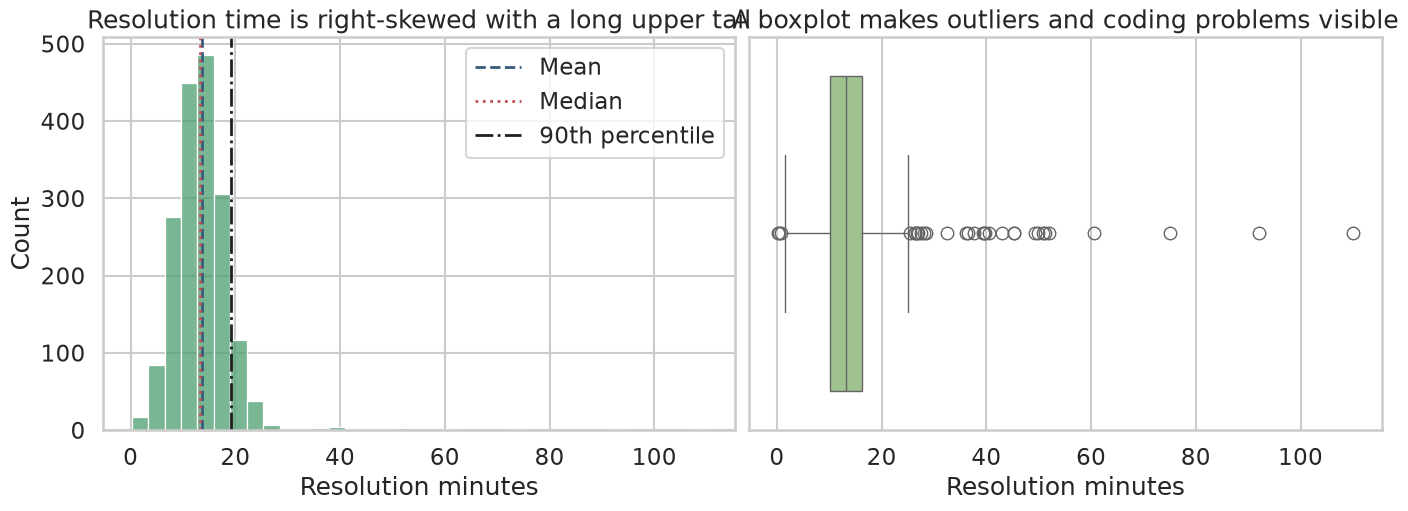

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
resolution = support_eda["resolution_minutes"]
resolution_summary = pd.DataFrame(
    [
        {"statistic": "Mean", "value": resolution.mean()},
        {"statistic": "Median", "value": resolution.median()},
        {"statistic": "10% trimmed mean", "value": stats.trim_mean(resolution, 0.10)},
        {"statistic": "Standard deviation", "value": resolution.std()},
        {"statistic": "IQR", "value": resolution.quantile(0.75) - resolution.quantile(0.25)},
        {"statistic": "90th percentile", "value": resolution.quantile(0.90)},
        {"statistic": "99th percentile", "value": resolution.quantile(0.99)},
        {"statistic": "Share above 20 minutes", "value": (resolution > 20).mean()},
        {"statistic": "Count below 1 minute", "value": (resolution < 1).sum()},
        {"statistic": "Count above 60 minutes", "value": (resolution > 60).sum()},
    ]
)

smart_display(resolution_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0), constrained_layout=True)

sns.histplot(support_eda, x="resolution_minutes", bins=35, color="#4C9F70", edgecolor="white", ax=axes[0])
axes[0].axvline(resolution.mean(), color="#355C7D", linestyle="--", linewidth=2, label="Mean")
axes[0].axvline(resolution.median(), color="#C44E52", linestyle=":", linewidth=2, label="Median")
axes[0].axvline(resolution.quantile(0.90), color="#1f1f1f", linestyle="-.", linewidth=2, label="90th percentile")
axes[0].set_title("Resolution time is right-skewed with a long upper tail")
axes[0].set_xlabel("Resolution minutes")
axes[0].set_ylabel("Count")
axes[0].legend()

sns.boxplot(data=support_eda, x="resolution_minutes", color="#9CCB86", ax=axes[1])
axes[1].set_title("A boxplot makes outliers and coding problems visible")
axes[1].set_xlabel("Resolution minutes")

plt.show()



The mean and median are fairly close. Their difference still reminds us that the distribution is asymmetric. The 90th and 99th percentiles tell a much stronger story about tail risk than the mean does.

The boxplot also exposes something more serious: there are values that look implausible for the process definition itself, including sub-minute resolutions and extremely large cases. Some may be legitimate edge cases, but some are likely coding or logging problems. EDA is where we notice that before those values quietly distort a model fit.


## 4. Group Comparisons Need Context and Ranking

Once the marginal distribution is understood, we usually want subgroup comparisons. But ranking channels or regions by average resolution time can be misleading if those groups face systematically different case mixes.

A useful exploratory habit is to compare both:

- a performance metric such as median or tail time, and
- the underlying group sizes that tell us how much evidence sits behind each cell.


,tickets,mean_minutes,median_minutes,p90_minutes,breach_rate
channel,,,,,
Chat,961,12.7448,12.2548,18.0284,0.0499
Email,601,14.4859,13.7531,20.1818,0.0666
Phone,238,14.9569,14.7115,20.2357,0.0630


,severity,channel,tickets,median_minutes,p90_minutes
6,Low,Chat,285,10.8295,16.6532
7,Low,Email,177,12.4155,17.1607
8,Low,Phone,63,13.8331,18.5589
9,Medium,Chat,382,11.7996,16.8635
10,Medium,Email,234,13.3404,18.2350
11,Medium,Phone,87,13.3143,18.0787
3,High,Chat,214,13.7803,18.8810
4,High,Email,127,14.7048,20.2013
5,High,Phone,68,16.1545,21.1027
0,Critical,Chat,80,17.2905,23.1800


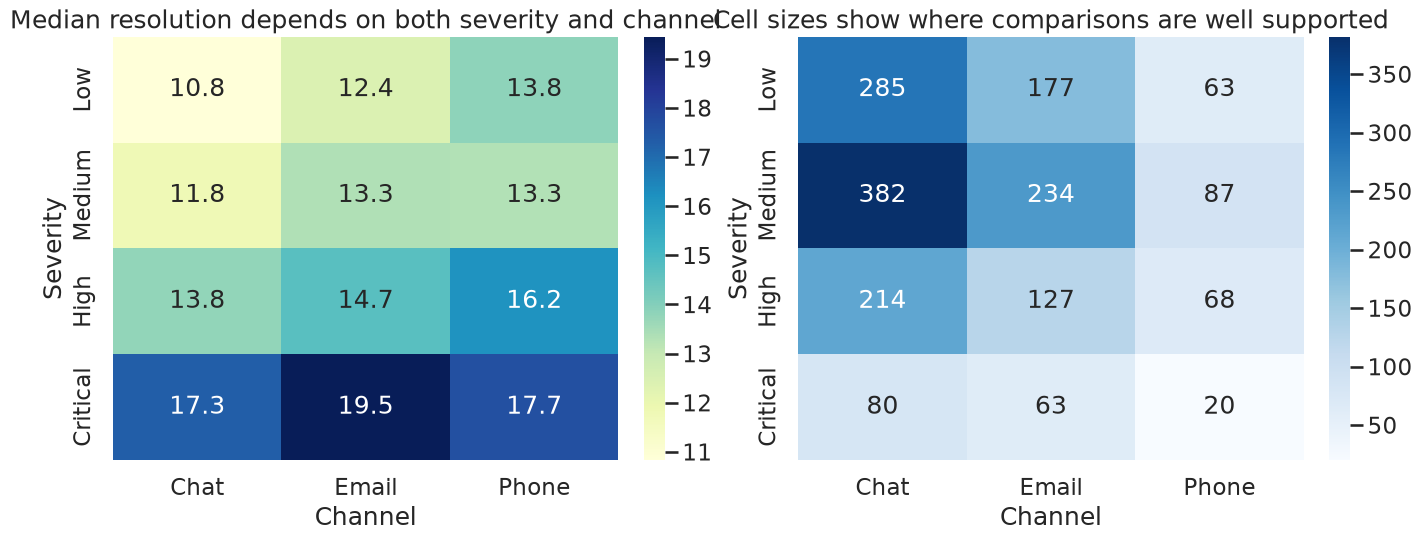

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
severity_order = ["Low", "Medium", "High", "Critical"]
channel_order = ["Chat", "Email", "Phone"]

channel_summary = (
    support_eda.groupby("channel")
    .agg(
        tickets=("resolution_minutes", "size"),
        mean_minutes=("resolution_minutes", "mean"),
        median_minutes=("resolution_minutes", "median"),
        p90_minutes=("resolution_minutes", lambda s: s.quantile(0.90)),
        breach_rate=("sla_breach", "mean"),
    )
    .reindex(channel_order)
)

conditional_summary = (
    support_eda.groupby(["severity", "channel"])
    .agg(
        tickets=("resolution_minutes", "size"),
        median_minutes=("resolution_minutes", "median"),
        p90_minutes=("resolution_minutes", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)
conditional_summary["severity"] = pd.Categorical(conditional_summary["severity"], categories=severity_order, ordered=True)
conditional_summary["channel"] = pd.Categorical(conditional_summary["channel"], categories=channel_order, ordered=True)
conditional_summary = conditional_summary.sort_values(["severity", "channel"])

median_heatmap = conditional_summary.pivot(index="severity", columns="channel", values="median_minutes").reindex(index=severity_order, columns=channel_order)
count_heatmap = conditional_summary.pivot(index="severity", columns="channel", values="tickets").reindex(index=severity_order, columns=channel_order)

smart_display(channel_summary)
smart_display(conditional_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.3), constrained_layout=True)

sns.heatmap(median_heatmap, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Median resolution depends on both severity and channel")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Severity")

sns.heatmap(count_heatmap, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
axes[1].set_title("Cell sizes show where comparisons are well supported")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Severity")

plt.show()



The unconditional channel table suggests that chat is fastest, while phone and email are slower. That is true as a descriptive statement, but the conditional heatmap shows *why* the interpretation must be careful.

Severity and channel jointly shape the outcome. Some channel differences persist within severity bands, but some of the raw differences are also driven by case mix. This is a classic EDA lesson: if we only rank group means, we can mistake composition effects for pure workflow effects.


## 5. Missingness and Coding Problems Are Part of the Data-Generating Process

Missing values often encode operational behavior. They often encode operational behavior. For example, customer feedback may be less likely to arrive after poor experiences, and workforce metadata may be more likely to be absent in specific channels or regions.

EDA should therefore ask both *how much* is missing and *where* it is missing.


,variable,missing_pct
5,analyst_experience_years,4.8889
10,csat_score,4.2222
2,region,0.0000
1,channel,0.0000
0,seller_tier,0.0000
4,queue_load,0.0000
3,severity,0.0000
7,resolution_minutes,0.0000
6,first_reply_minutes,0.0000
8,repeat_contact,0.0000


,sla_breach,missing_share
0,No breach,0.0230
1,Breach,0.3592


,channel,missing_share
0,Chat,0.0114
1,Email,0.1265
2,Phone,0.0042


,seller_tier,channel,region,severity,resolution_minutes,sla_breach,escalated_refund
90,Long tail,Email,Asia Pacific,Low,0.200000,1,0
1318,Long tail,Phone,North America,High,0.400000,0,0
669,Strategic,Email,North America,High,0.800000,0,0
247,Enterprise,Email,North America,High,60.580171,1,0
447,Strategic,Email,Latin America,Low,75.000000,0,0
1010,Long tail,Chat,Asia Pacific,Low,92.000000,0,0
735,Growth,Email,North America,High,110.000000,0,0


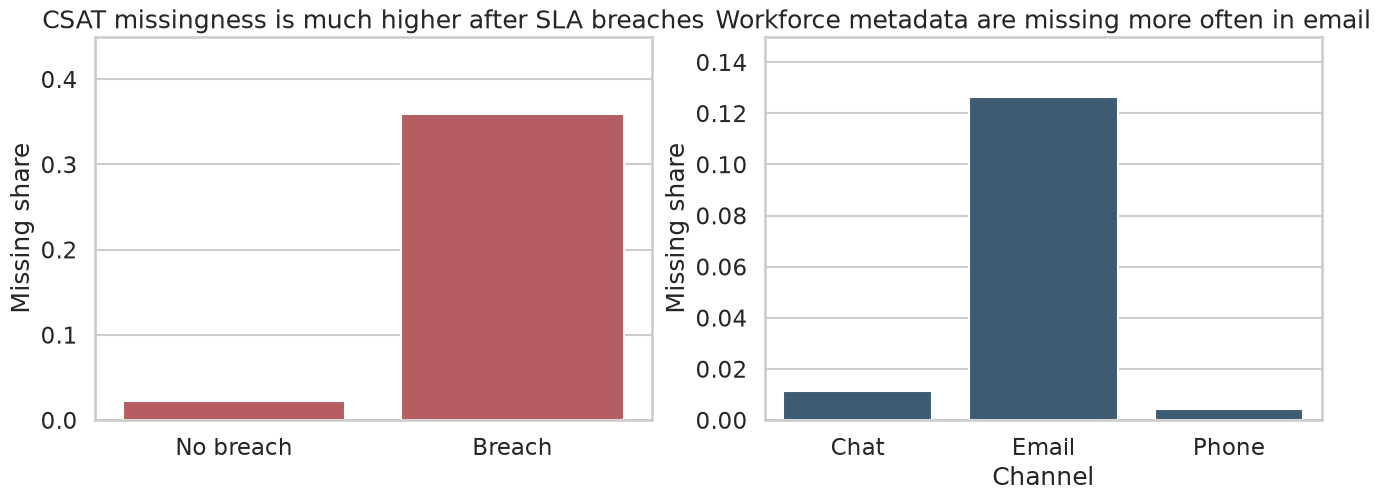

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
missing_summary = pd.DataFrame(
    {
        "variable": support_eda.columns,
        "missing_pct": [100 * support_eda[col].isna().mean() for col in support_eda.columns],
    }
).sort_values("missing_pct", ascending=False)

csat_missing_by_breach = (
    support_eda.assign(csat_missing=support_eda["csat_score"].isna())
    .groupby("sla_breach", as_index=False)["csat_missing"]
    .mean()
)
csat_missing_by_breach["sla_breach"] = csat_missing_by_breach["sla_breach"].map({0: "No breach", 1: "Breach"})
csat_missing_by_breach = csat_missing_by_breach.rename(columns={"csat_missing": "missing_share"})

experience_missing_by_channel = (
    support_eda.assign(experience_missing=support_eda["analyst_experience_years"].isna())
    .groupby("channel", as_index=False)["experience_missing"]
    .mean()
    .set_index("channel")
    .reindex(channel_order)
    .reset_index()
    .rename(columns={"experience_missing": "missing_share"})
)

suspicious_resolution_rows = support_eda.loc[
    (support_eda["resolution_minutes"] < 1) | (support_eda["resolution_minutes"] > 60),
    ["seller_tier", "channel", "region", "severity", "resolution_minutes", "sla_breach", "escalated_refund"],
].sort_values("resolution_minutes")

smart_display(missing_summary)
smart_display(csat_missing_by_breach)
smart_display(experience_missing_by_channel)
display_wrapped(suspicious_resolution_rows, max_width="220px")

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.9), constrained_layout=True)

sns.barplot(data=csat_missing_by_breach, x="sla_breach", y="missing_share", color="#C44E52", ax=axes[0])
axes[0].set_title("CSAT missingness is much higher after SLA breaches")
axes[0].set_xlabel("")
axes[0].set_ylabel("Missing share")
axes[0].set_ylim(0, 0.45)

sns.barplot(data=experience_missing_by_channel, x="channel", y="missing_share", color="#355C7D", ax=axes[1])
axes[1].set_title("Workforce metadata are missing more often in email")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Missing share")
axes[1].set_ylim(0, 0.15)

plt.show()


This section changes the modeling plan materially.

- CSAT is not missing at random; it is far more likely to be missing when tickets breach the SLA.
- Analyst-experience data are unevenly recorded across workflows.
- The suspicious resolution rows are obvious candidates for a cleaning rule or a manual audit.

If we ignore these patterns, later models may overstate satisfaction, understate operational risk, or learn from values that should never have entered the analysis in the first place.


## 6. Multivariable Exploration Should Surface Structure and Leakage

A final exploratory pass should look at joint structure among variables. We want to see broad relationships, but we also want to notice fields that are too strongly tied to the outcome because they occur *after* the process has unfolded.

That is what leakage looks like. A leaky feature can make a future predictive model look brilliant during training while being useless at the moment the decision must actually be made.


,refund_rate,ticket_count
sla_breach,,
No breach,0.0000,1697
Breach,0.1942,103


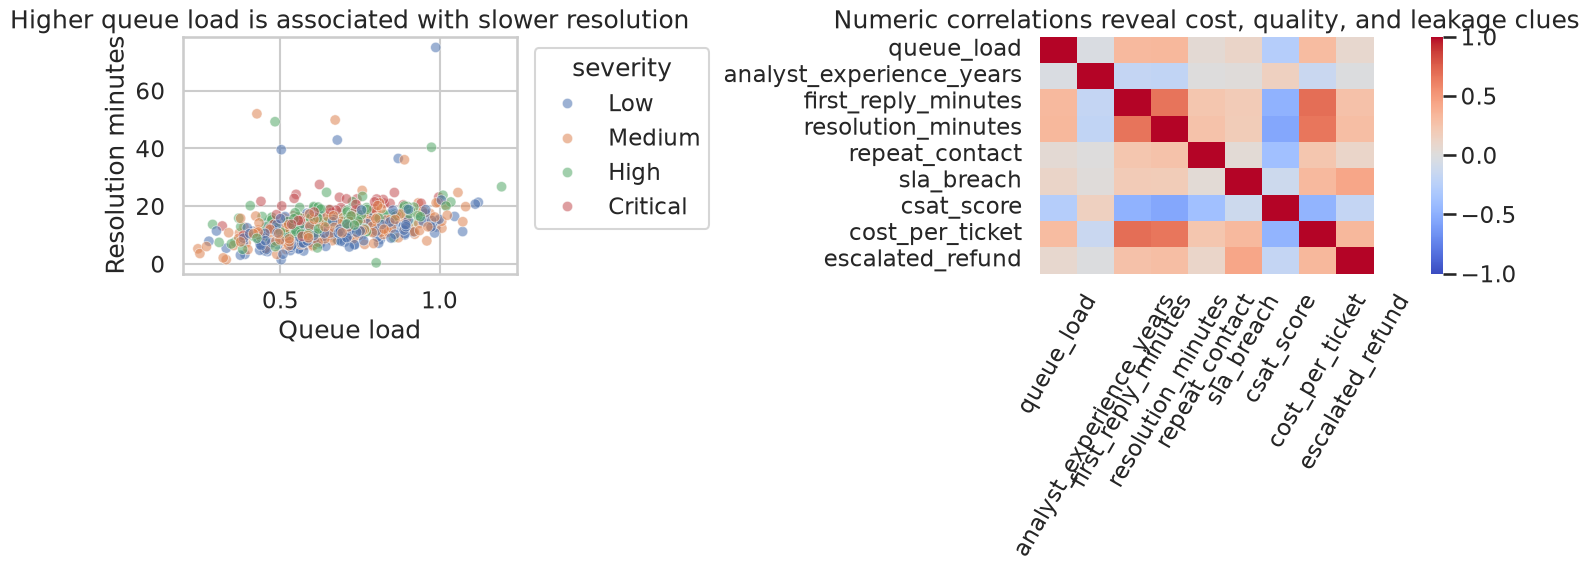

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
plot_sample = support_eda.sample(600, random_state=7).copy()
plot_sample["severity"] = pd.Categorical(plot_sample["severity"], categories=severity_order, ordered=True)

numeric_cols = [
    "queue_load",
    "analyst_experience_years",
    "first_reply_minutes",
    "resolution_minutes",
    "repeat_contact",
    "sla_breach",
    "csat_score",
    "cost_per_ticket",
    "escalated_refund",
]
correlation_matrix = support_eda[numeric_cols].corr(numeric_only=True)

leakage_table = pd.DataFrame(
    {
        "refund_rate": support_eda.groupby("sla_breach")["escalated_refund"].mean(),
        "ticket_count": support_eda.groupby("sla_breach")["escalated_refund"].size(),
    }
)
leakage_table.index = leakage_table.index.map({0: "No breach", 1: "Breach"})

smart_display(leakage_table)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.6), constrained_layout=True)

sns.scatterplot(
    data=plot_sample,
    x="queue_load",
    y="resolution_minutes",
    hue="severity",
    alpha=0.55,
    s=55,
    ax=axes[0],
)
axes[0].set_title("Higher queue load is associated with slower resolution")
axes[0].set_xlabel("Queue load")
axes[0].set_ylabel("Resolution minutes")
axes[0].legend(title="severity", loc="upper left", bbox_to_anchor=(1.02, 1.0))

sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Numeric correlations reveal cost, quality, and leakage clues")
axes[1].tick_params(axis="x", rotation=60)
axes[1].tick_params(axis="y", rotation=0)

plt.show()



The scatterplot suggests that queue congestion and severity both matter for resolution time, which is exactly the kind of structure a later model would need to capture.

The more subtle finding comes from the leakage table and the correlation heatmap. `escalated_refund` occurs only after service failure patterns have already emerged. That makes it a dangerous predictor if the goal is to forecast risk at intake time. A later model that includes it may appear highly accurate while quietly cheating.


## 7. EDA Handoff Checklist

| Before modeling | Why it matters |
| --- | --- |
| Define which variables are available at decision time | Prevents leakage and unrealistic performance estimates |
| Decide how to treat implausible values | Outliers may be errors, edge cases, or both |
| Characterize missingness before imputation | Missingness may itself carry operational meaning |
| Use robust summaries for skewed service metrics | Means alone hide tail behavior and SLA risk |
| Keep subgroup sample sizes visible | Conditional structure is easy to overread in sparse cells |
| Record the exploratory conclusions in plain language | Makes later modeling choices auditable and less ad hoc |



## 8. Decision Readout from This EDA

The goal of an exploratory notebook is not to end with a final model. It is to end with a sharper modeling plan and a cleaner statement of what the dataset can and cannot yet support.


In [8]:
# Build a summary table that supports the interpretation in the surrounding notes.
invalid_resolution_count = ((support_eda["resolution_minutes"] < 1) | (support_eda["resolution_minutes"] > 60)).sum()
csat_missing_breach = csat_missing_by_breach.loc[csat_missing_by_breach["sla_breach"] == "Breach", "missing_share"].iloc[0]
csat_missing_no_breach = csat_missing_by_breach.loc[csat_missing_by_breach["sla_breach"] == "No breach", "missing_share"].iloc[0]
refund_rate_breach = leakage_table.loc["Breach", "refund_rate"]
refund_rate_no_breach = leakage_table.loc["No breach", "refund_rate"]

eda_readout = pd.DataFrame(
    [
        {
            "finding": "Outcome distribution is right-skewed with a meaningful upper tail",
            "evidence": f"Median = {resolution.median():.2f} min, p90 = {resolution.quantile(0.90):.2f} min, p99 = {resolution.quantile(0.99):.2f} min",
            "why_it_matters": "Models and dashboards should track tail behavior, average performance and tail behavior.",
            "recommended_next_step": "Retain median and upper-quantile summaries in all subsequent analyses.",
        },
        {
            "finding": "Some recorded resolution values are implausible",
            "evidence": f"{invalid_resolution_count} rows are below 1 minute or above 60 minutes",
            "why_it_matters": "Potential coding issues can distort coefficients, loss functions, and business rules.",
            "recommended_next_step": "Create a cleaning rule or an audit queue before formal modeling.",
        },
        {
            "finding": "CSAT missingness is strongly outcome-dependent",
            "evidence": f"Missing after breach = {csat_missing_breach:.1%}; missing without breach = {csat_missing_no_breach:.1%}",
            "why_it_matters": "Naive analyses of customer satisfaction will be biased toward smoother cases.",
            "recommended_next_step": "Treat CSAT missingness as informative.",
        },
        {
            "finding": "Refund escalation is a leakage variable for intake-time prediction",
            "evidence": f"Refund rate with no breach = {refund_rate_no_breach:.1%}; refund rate with breach = {refund_rate_breach:.1%}",
            "why_it_matters": "Including downstream artifacts can make future models look accurate for the wrong reason.",
            "recommended_next_step": "Exclude `escalated_refund` from any model intended for early risk prediction.",
        },
    ]
)

display_wrapped(eda_readout, max_width="320px")

smart_display(
    Markdown(
        "The exploratory evidence supports a **careful modeling handoff before a modeling sprint**. "
        "A defensible next step would be to clean implausible resolution values, keep robust tail summaries in scope, "
        "document non-random missingness, and quarantine post-outcome variables such as `escalated_refund`."
    )
)


,finding,evidence,why_it_matters,recommended_next_step
0,Outcome distribution is right-skewed with a meaningful upper tail,"Median = 13.15 min, p90 = 19.09 min, p99 = 36.10 min","Models and dashboards should track tail behavior, average performance and tail behavior.",Retain median and upper-quantile summaries in all subsequent analyses.
1,Some recorded resolution values are implausible,7 rows are below 1 minute or above 60 minutes,"Potential coding issues can distort coefficients, loss functions, and business rules.",Create a cleaning rule or an audit queue before formal modeling.
2,CSAT missingness is strongly outcome-dependent,Missing after breach = 35.9%; missing without breach = 2.3%,Naive analyses of customer satisfaction will be biased toward smoother cases.,Treat CSAT missingness as informative.
3,Refund escalation is a leakage variable for intake-time prediction,Refund rate with no breach = 0.0%; refund rate with breach = 19.4%,Including downstream artifacts can make future models look accurate for the wrong reason.,Exclude `escalated_refund` from any model intended for early risk prediction.


The exploratory evidence supports a **careful modeling handoff before a modeling sprint**. A defensible next step would be to clean implausible resolution values, keep robust tail summaries in scope, document non-random missingness, and quarantine post-outcome variables such as `escalated_refund`.

This readout turns exploration into a decision inventory. It identifies what looks trustworthy, what needs cleaning, and which patterns are strong enough to guide the next analysis.



## Wrap-Up

Good EDA is a structured investigation, with charts serving the argument. It is a structured attempt to understand measurement, shape, quality, subgroup structure, and modeling risk before we commit to formal inference.

In this dataset, the main exploratory conclusions were not cosmetic:

- the outcome has meaningful tail risk,
- subgroup differences are partly compositional,
- missingness is informative,
- some values need cleaning, and
- at least one variable is too downstream to use safely in predictive modeling.

That is exactly the kind of knowledge that should change what we do next.


## 9. Real-Data Companion: EDA on NYC 311 Resolution Times

Synthetic EDA is useful because we can design specific pitfalls. Real EDA is useful because the pitfalls arrive without asking permission. NYC 311 service-request data provide messy categories, missing fields, long-tailed resolution times, uneven agency volumes, and strong differences across complaint types and boroughs.

In this companion, each row is a service request with timing fields such as created date and closed date. From those timestamps we can derive a resolution-time outcome, but that outcome is only meaningful after checking closure status, missing dates, extremely long durations, complaint-type mix, and agency mix. A resolution-time plot without that context can easily compare unlike workloads.

The experiment is a first-pass data audit. We are not building a final service-quality model or ranking agencies. We are asking whether the extract is coherent enough for modeling, what transformations are needed, where tail behavior appears, and which subgroup summaries should accompany any later statistical analysis.

For clarity, the unit is a service request. The main outcome is derived resolution time, and the companion also inspects complaint mix, agency mix, missingness, and tail behavior. The experiment is an EDA workflow, not a causal study: audit the dataset before deciding what modeling is safe.

Data source: [NYC Open Data 311 Service Requests](https://data.cityofnewyork.us/api/views/erm2-nwe9).

,quantity,value
0,Rows,4997.000000
1,Complaint types,76.000000
2,Agencies,9.000000
3,Boroughs,6.000000
4,Missing borough rate,0.000000
5,Median resolution hours,1.038000
6,90th percentile resolution hours,4.717000


,agency,requests,median_hours,p90_hours
0,DSNY,195,0.5700,11.4500
1,DOT,181,1.8000,8.8000
2,DHS,89,2.2400,8.0500
3,NYPD,3957,1.1300,4.3200
4,DPR,60,1.1800,4.0700
5,DEP,146,0.2700,2.9100
6,DOB,334,0.0000,0.0000


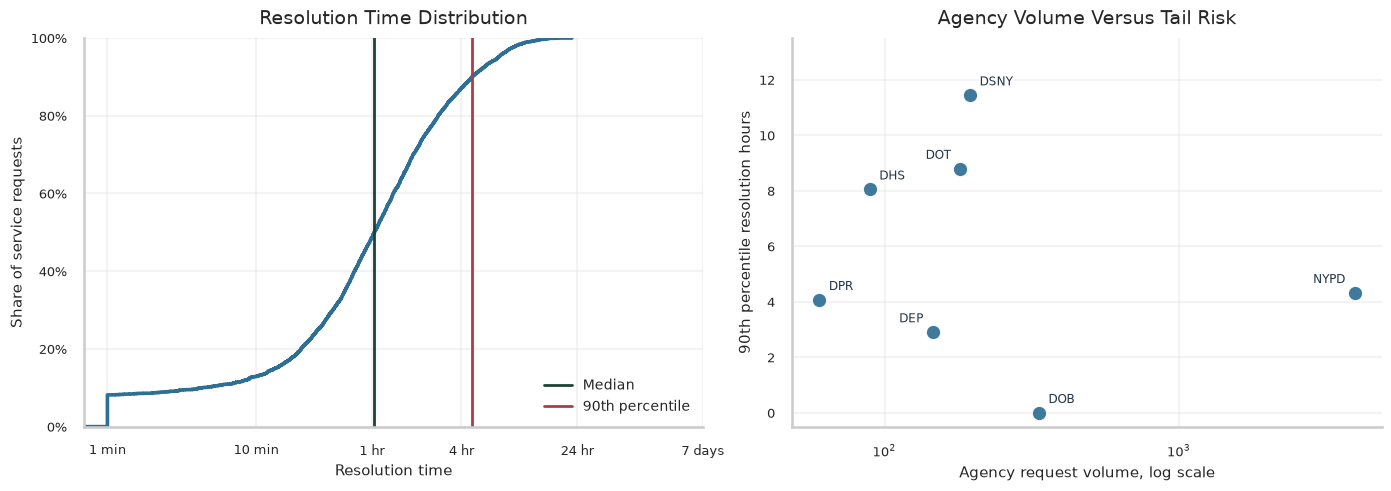

In [9]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import fetch_nyc_311, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    nyc_311 = fetch_nyc_311(limit=7_500, start_date="2025-01-01")
    nyc_311["resolution_hours"] = (
        nyc_311["closed_date"] - nyc_311["created_date"]
    ).dt.total_seconds() / 3600
    nyc_311 = nyc_311.query("0 <= resolution_hours <= 720").copy()

    audit = pd.DataFrame(
        {
            "quantity": [
                "Rows",
                "Complaint types",
                "Agencies",
                "Boroughs",
                "Missing borough rate",
                "Median resolution hours",
                "90th percentile resolution hours",
            ],
            "value": [
                len(nyc_311),
                nyc_311["complaint_type"].nunique(),
                nyc_311["agency"].nunique(),
                nyc_311["borough"].nunique(),
                nyc_311["borough"].isna().mean(),
                nyc_311["resolution_hours"].median(),
                nyc_311["resolution_hours"].quantile(0.90),
            ],
        }
    )

    agency_summary = (
        nyc_311.groupby("agency", dropna=False)
        .agg(
            requests=("unique_key", "count"),
            median_hours=("resolution_hours", "median"),
            p90_hours=("resolution_hours", lambda s: s.quantile(0.90)),
        )
        .query("requests >= 50")
        .sort_values("p90_hours", ascending=False)
        .reset_index()
    )

    smart_display(audit.round(3))
    smart_display(agency_summary.head(12).round(2))

    from matplotlib.ticker import PercentFormatter

    median_hours = nyc_311["resolution_hours"].median()
    p90_hours = nyc_311["resolution_hours"].quantile(0.90)
    resolution_for_plot = nyc_311["resolution_hours"].clip(lower=1 / 60)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13.8, 4.8),
        gridspec_kw={"width_ratios": [1.05, 1.0]},
        constrained_layout=True,
    )

    sns.ecdfplot(
        x=resolution_for_plot,
        ax=axes[0],
        color="#2E6F95",
        linewidth=2.6,
    )
    axes[0].axvline(median_hours, color="#1B4332", linewidth=2.0, label="Median")
    axes[0].axvline(p90_hours, color="#B23A48", linewidth=2.0, label="90th percentile")
    axes[0].set_xscale("log")
    axes[0].set_xticks([1 / 60, 1 / 6, 1, 4, 24, 168])
    axes[0].set_xticklabels(["1 min", "10 min", "1 hr", "4 hr", "24 hr", "7 days"])
    axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    axes[0].set_title("Resolution Time Distribution", fontsize=14, pad=10)
    axes[0].set_xlabel("Resolution time", fontsize=11)
    axes[0].set_ylabel("Share of service requests", fontsize=11)
    axes[0].legend(frameon=False, loc="lower right", fontsize=10)

    sns.scatterplot(
        data=agency_summary,
        x="requests",
        y="p90_hours",
        color="#2E6F95",
        edgecolor="white",
        linewidth=1.0,
        alpha=0.92,
        s=110,
        ax=axes[1],
    )
    axes[1].set_xscale("log")
    axes[1].set_ylim(-0.5, agency_summary["p90_hours"].max() * 1.18)
    axes[1].set_title("Agency Volume Versus Tail Risk", fontsize=14, pad=10)
    axes[1].set_xlabel("Agency request volume, log scale", fontsize=11)
    axes[1].set_ylabel("90th percentile resolution hours", fontsize=11)

    for row_number, row in agency_summary.iterrows():
        x_offset = 7 if row_number % 2 == 0 else -7
        alignment = "left" if x_offset > 0 else "right"
        axes[1].annotate(
            str(row["agency"]),
            xy=(row["requests"], row["p90_hours"]),
            xytext=(x_offset, 5),
            textcoords="offset points",
            ha=alignment,
            va="bottom",
            fontsize=8.5,
            color="#243447",
            bbox={"boxstyle": "round,pad=0.16", "fc": "white", "ec": "none", "alpha": 0.78},
        )

    for ax in axes:
        ax.grid(True, axis="both", alpha=0.22)
        ax.tick_params(labelsize=9.5)

    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "NYC 311 Service Requests",
        "https://data.cityofnewyork.us/api/views/erm2-nwe9",
        "RUN_REAL_DATA_COMPANION",
    )

A real EDA handoff should include warnings about definitions, missingness, time coverage, tail behavior, and category drift. The 311 companion makes those warnings concrete. The ECDF uses a log-scaled time axis because resolution time is strongly right-skewed; near-zero values are floored at one minute only for display. The median and 90th percentile markers separate typical service speed from tail risk.

The agency panel makes a second point that an average table can hide: volume and tail performance are different diagnostics. A high-volume agency is not automatically the slowest in the tail, and a smaller agency can still have meaningful operational risk if its 90th percentile is high. That is exactly why EDA should precede modeling, dashboards, and policy recommendations.


## References

- Morgenthaler, S. (2009). *Exploratory data analysis*. *WIREs Computational Statistics, 1*(1), 33-44. [https://doi.org/10.1002/wics.2](https://doi.org/10.1002/wics.2)
- Anscombe, F. J. (1973). *Graphs in statistical analysis*. The American Statistician, 27(1), 17-21. [https://doi.org/10.1080/00031305.1973.10478966](https://doi.org/10.1080/00031305.1973.10478966)
- Cleveland, W. S., & McGill, R. (1984). *Graphical perception: Theory, experimentation, and application to the development of graphical methods*. Journal of the American Statistical Association, 79(387), 531-554. [https://doi.org/10.2307/2288400](https://doi.org/10.2307/2288400)
- Wainer, H. (1984). *How to display data badly*. The American Statistician, 38(2), 137-147. [https://doi.org/10.2307/2683253](https://doi.org/10.2307/2683253)
